# OLIST SELLER CHURN - MACHINE LEARNING

## Import Library

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import duckdb
import re
import seaborn as sns
import kagglehub
from lonboard import viz
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import stats
import os
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import fbeta_score, make_scorer, recall_score, confusion_matrix, get_scorer_names, classification_report

import pickle

import warnings

In [2]:
duckdb.sql("LOAD SPATIAL;")

## Import Data

The dataset was downloaded from Kaggle

In [ ]:
dataset = {
    'customers_df'              : 'olist_customers_dataset',
    'geolocation_df'            : 'olist_geolocation_dataset',
    'items_df'                  : 'olist_order_items_dataset',
    'payments_df'               : 'olist_order_payments_dataset',
    'reviews_df'                : 'olist_order_reviews_dataset',
    'orders_df'                 : 'olist_orders_dataset',
    'products_df'               : 'olist_products_dataset',
    'sellers_df'                : 'olist_sellers_dataset',
    'products_category_df'      : 'product_category_name_translation'
}

load_dotenv() 

dfs = {}
for df_name, df in tqdm(dataset.items(), total=len(dataset), desc='Import Data: '):
    dfs[df_name] = pd.read_csv(f"{os.getenv('data_path')}/{df}.csv")

globals().update(dfs)

Import Data: 100%|██████████| 9/9 [00:01<00:00,  6.78it/s]


## Data Cleaning

In [4]:
df_list = []
for i in dfs.keys():
    dataframe_obj = globals()[i] 
    df_list.append(dataframe_obj)

In [5]:
def convert_timestamp(df):
    for i in df.columns:
        if re.search(r'timestamp|_at|_date', i, flags=re.IGNORECASE):
            df[i] = df[i].astype('timestamp[s][pyarrow]')


for i in df_list:
    convert_timestamp(i)

In [6]:
products_df_group = products_df['product_category_name'].value_counts(dropna=False).reset_index()
products_group_english_df = products_df_group.merge(products_category_df, on='product_category_name', how='left')
products_group_english_df = products_group_english_df[['product_category_name', 'product_category_name_english', 'count']]
missing_product_english = products_group_english_df[products_group_english_df['product_category_name_english'].isna()][['product_category_name']].dropna()
missing_product_english['product_category_name_english'] = ['kitchen_appliances_and_food_prep', 'pc_games']
products_category_df = pd.concat([products_category_df, missing_product_english])
products_category_df

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes
70,seguros_e_servicos,security_and_services
66,portateis_cozinha_e_preparadores_de_alimentos,kitchen_appliances_and_food_prep


In [7]:
dfs_dict = {
    'geolocation': geolocation_df, 
    'reviews': reviews_df, 
    'products': products_df
}

for name, df in dfs_dict.items():
    if name != 'products':
        df.drop_duplicates(inplace=True)
    else:
        df.dropna(inplace=True)


In [8]:
query = """
SELECT
    geolocation_zip_code_prefix,
    geolocation_city,
    geolocation_state,
    ST_Point(geolocation_lng, geolocation_lat) AS geometry
FROM
    geolocation_df
ORDER BY 1
"""

geolocation_db = duckdb.sql(query)
geolocation_db

┌─────────────────────────────┬──────────────────┬───────────────────┬────────────────────────────────────────────────┐
│ geolocation_zip_code_prefix │ geolocation_city │ geolocation_state │                    geometry                    │
│            int64            │     varchar      │      varchar      │                    geometry                    │
├─────────────────────────────┼──────────────────┼───────────────────┼────────────────────────────────────────────────┤
│                        1001 │ são paulo        │ SP                │ POINT (-46.6339571183853 -23.549779299469115)  │
│                        1001 │ sao paulo        │ SP                │ POINT (-46.63396956010149 -23.5498252739339)   │
│                        1001 │ são paulo        │ SP                │ POINT (-46.63402708563671 -23.549951273933896) │
│                        1001 │ sao paulo        │ SP                │ POINT (-46.63433817805407 -23.55049770690751)  │
│                        1001 │ sao paul

In [9]:
query = f"""
SELECT
    * EXCLUDE(geom),
    ST_GeomFromText(ST_AsText(geom)) AS geometry
FROM
    ST_Read('{os.getenv('data_path_geo')}/geoBoundaries-BRA-ADM0.geojson')
"""

brazil_boundary = duckdb.sql(query)
brazil_boundary

┌─────────┬───────────┬──────────┬─────────────────────────┬────────────┬───────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [10]:
query = """
SELECT
    a.geolocation_zip_code_prefix,
    a.geolocation_city,
    a.geolocation_state,
    ST_Y(a.geometry) AS latitude,
    ST_X(a.geometry) AS longitude
FROM
    geolocation_db AS a
INNER JOIN
    brazil_boundary AS b
ON
    ST_Within(a.geometry, b.geometry)
"""

geolocation_clean_db = duckdb.sql(query)
geolocation_clean_db

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────────────┬──────────────────┬───────────────────┬─────────────────────┬─────────────────────┐
│ geolocation_zip_code_prefix │ geolocation_city │ geolocation_state │      latitude       │      longitude      │
│            int64            │     varchar      │      varchar      │       double        │       double        │
├─────────────────────────────┼──────────────────┼───────────────────┼─────────────────────┼─────────────────────┤
│                        1001 │ são paulo        │ SP                │ -23.549779299469115 │   -46.6339571183853 │
│                        1001 │ sao paulo        │ SP                │   -23.5498252739339 │  -46.63396956010149 │
│                        1001 │ são paulo        │ SP                │ -23.549951273933896 │  -46.63402708563671 │
│                        1001 │ sao paulo        │ SP                │  -23.55049770690751 │  -46.63433817805407 │
│                        1001 │ sao paulo        │ SP                │ -23.55142

In [11]:
query = """
SELECT
    geolocation_zip_code_prefix,
    MEDIAN(latitude) AS geolocation_lat,
    MEDIAN(longitude) AS geolocation_lng,
    MODE(strip_accents(geolocation_city)) AS geolocation_city,
    MODE(geolocation_state) AS geolocation_state
FROM
    geolocation_clean_db
GROUP BY 1
ORDER BY 1 ASC
"""

geolocation_df = duckdb.sql(query).to_df()
geolocation_df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.549951,-46.634027,sao paulo,SP
1,1002,-23.548228,-46.635247,sao paulo,SP
2,1003,-23.548977,-46.635313,sao paulo,SP
3,1004,-23.549550,-46.634771,sao paulo,SP
4,1005,-23.549763,-46.636100,sao paulo,SP
...,...,...,...,...,...
19006,99960,-27.953797,-52.029641,charrua,RS
19007,99965,-28.179542,-52.035551,agua santa,RS
19008,99970,-28.343257,-51.875470,ciriaco,RS
19009,99980,-28.388342,-51.846871,david canabarro,RS


In [16]:
customers_df = customers_df.drop(columns=['customer_city', 'customer_state'])
sellers_df = sellers_df.drop(columns=['seller_city', 'seller_state'])

In [24]:
dataset_clean = {
    'customers_df'              : customers_df,
    'geolocation_df'            : geolocation_df,
    'items_df'                  : items_df,
    'payments_df'               : payments_df,
    'reviews_df'                : reviews_df,
    'orders_df'                 : orders_df,
    'products_df'               : products_df,
    'sellers_df'                : sellers_df,
    'products_category_df'      : products_category_df
}

for key,value in dataset_clean.items():
    print(f"{key}: {value.shape}")

customers_df: (99441, 3)
geolocation_df: (19011, 5)
items_df: (112650, 7)
payments_df: (103886, 5)
reviews_df: (99224, 7)
orders_df: (99441, 8)
products_df: (32340, 9)
sellers_df: (3095, 2)
products_category_df: (73, 2)


## Exploratory Data Analysis

In [35]:
query = """
WITH cutoff_cte AS (
SELECT
  DATE_ADD(MAX(order_delivered_carrier_date), INTERVAL '-30' DAY) AS cutoff_date
FROM
  orders_df
WHERE
  order_delivered_carrier_date IS NOT NULL
)

, order_data AS (
SELECT
  a.seller_id,
  COUNT(DISTINCT c.order_id) AS total_order,
  MIN(c.order_delivered_carrier_date) AS min_order_delivered_carrier_date,
  MAX(c.order_delivered_carrier_date) AS max_order_delivered_carrier_date
FROM
  sellers_df AS a
LEFT JOIN
  items_df AS b
ON
  a.seller_id = b.seller_id
LEFT JOIN
  (SELECT * FROM orders_df WHERE order_delivered_carrier_date IS NOT NULL)AS c
ON
  b.order_id = c.order_id
GROUP BY ALL
)

, final_data AS (
SELECT
  a.*,
  b.cutoff_date,
  CASE
    WHEN a.total_order = 0 THEN 'not eligible'
    WHEN a.min_order_delivered_carrier_date >= DATE_ADD(b.cutoff_date, INTERVAL '-30' DAY) THEN 'not eligible'
    WHEN a.max_order_delivered_carrier_date>=b.cutoff_date THEN 'active'
    ELSE 'churn'
  END AS churn_status
FROM
  order_data AS a
CROSS JOIN
  cutoff_cte AS b
)

SELECT
  *
FROM
  final_data
;
"""

churn_cutoff_details = duckdb.sql(query).to_df()
churn_cutoff_details

,seller_id,total_order,min_order_delivered_carrier_date,max_order_delivered_carrier_date,cutoff_date,churn_status
0,4cf490a58259286ada5ba8525ba9e84a,8,2017-03-22 13:46:07,2017-12-12 14:40:10,2018-08-12 19:48:28,churn
1,116ccb1a1604bc88e4d234a8c23f33de,61,2017-11-10 22:18:48,2018-08-22 13:00:00,2018-08-12 19:48:28,active
2,430315b7bb4b6e4b3c978f9dfa9b0558,20,2018-01-15 20:22:42,2018-08-10 15:50:00,2018-08-12 19:48:28,churn
3,406822777a0b9eb5c50e442dd4cd3ec5,45,2017-11-06 21:36:21,2018-08-23 12:41:00,2018-08-12 19:48:28,active
4,4dbd95a08b31ede5c82d3f861cb1ce1a,4,2017-05-24 09:21:16,2017-11-14 22:11:53,2018-08-12 19:48:28,churn
...,...,...,...,...,...,...
3090,15ac3c501e2599e4917316fde5c5669a,0,NaT,NaT,2018-08-12 19:48:28,not eligible
3091,20fd2d2080ed85fa67fad3fcbb2c1813,0,NaT,NaT,2018-08-12 19:48:28,not eligible
3092,f0563bacf40c311f1c4d3d6b67b8a7a7,0,NaT,NaT,2018-08-12 19:48:28,not eligible
3093,64b87978a11c1ea7501a89eabe8c2c1a,0,NaT,NaT,2018-08-12 19:48:28,not eligible


In [36]:
churn_cutoff_details['churn_status'].value_counts()

churn_status
churn           1818
active           874
not eligible     403
Name: count, dtype: int64

In [37]:
query = """
WITH cutoff AS (
    SELECT MAX(CAST(cutoff_date AS TIMESTAMP)) AS cutoff_date   -- ← cast di sini
    FROM churn_cutoff_details
),

geo AS (
    SELECT
        geolocation_zip_code_prefix AS zip_prefix,
        AVG(geolocation_lat)        AS lat,
        AVG(geolocation_lng)        AS lng,
        MODE(geolocation_city)      AS city,
        MODE(geolocation_state)     AS state
    FROM geolocation_df
    GROUP BY ALL
),

seller_geo AS (
    SELECT s.seller_id, s.seller_zip_code_prefix,
           g.lat AS seller_lat, g.lng AS seller_lng,
           g.city AS seller_city, g.state AS seller_state
    FROM sellers_df AS s
    LEFT JOIN geo AS g ON s.seller_zip_code_prefix = g.zip_prefix
),

customer_geo AS (
    SELECT c.customer_id, c.customer_unique_id,
           g.lat AS customer_lat, g.lng AS customer_lng,
           g.state AS customer_state
    FROM customers_df AS c
    LEFT JOIN geo AS g ON c.customer_zip_code_prefix = g.zip_prefix
),

orders_base AS (
    SELECT
        order_id, customer_id, order_status,
        CAST(order_purchase_timestamp      AS TIMESTAMP) AS order_purchase_timestamp,
        CAST(order_delivered_carrier_date  AS TIMESTAMP) AS order_delivered_carrier_date,
        CAST(order_delivered_customer_date AS TIMESTAMP) AS order_delivered_customer_date,
        CAST(order_estimated_delivery_date AS TIMESTAMP) AS order_estimated_delivery_date
    FROM orders_df
),

orders_cutoff AS (
    SELECT o.*, c.cutoff_date
    FROM orders_base AS o 
    CROSS JOIN cutoff AS c
    WHERE o.order_delivered_carrier_date IS NOT NULL
      AND o.order_delivered_carrier_date <= c.cutoff_date
),

reviews AS (
    SELECT order_id, AVG(review_score) AS review_score
    FROM reviews_df
    GROUP BY ALL
),

payments AS (
    SELECT
        order_id,
        MAX(payment_installments) AS max_installments,
        SUM(payment_value)        AS payment_value,
        MAX(CASE WHEN payment_type = 'credit_card' THEN 1 ELSE 0 END) AS has_credit_card,
        MAX(CASE WHEN payment_type = 'boleto'      THEN 1 ELSE 0 END) AS has_boleto,
        MAX(CASE WHEN payment_type = 'voucher'     THEN 1 ELSE 0 END) AS has_voucher,
        MAX(CASE WHEN payment_type = 'debit_card'  THEN 1 ELSE 0 END) AS has_debit_card
    FROM payments_df
    GROUP BY ALL
),

items AS (
    SELECT
        order_id,
        seller_id,
        COUNT(*)                   AS n_items,
        COUNT(DISTINCT product_id) AS n_unique_products,
        SUM(price)                 AS price,
        SUM(freight_value)         AS freight_value
    FROM items_df
    GROUP BY ALL
),

sellers_per_order AS (
    SELECT order_id, COUNT(DISTINCT seller_id) AS n_sellers_in_order
    FROM items_df
    GROUP BY ALL
),

product_attrs AS (
    SELECT
        i.order_id,
        i.seller_id,
        AVG(p.product_weight_g)                                             AS avg_weight_g,
        AVG(p.product_length_cm * p.product_height_cm * p.product_width_cm) AS avg_volume_cm3,
        AVG(p.product_photos_qty)                                           AS avg_photos_qty,
        AVG(p.product_description_lenght)                                   AS avg_desc_length,
        AVG(p.product_name_lenght)                                          AS avg_name_length,
        MODE(c.product_category_name_english)                               AS main_category
    FROM items_df AS i
    LEFT JOIN products_df          AS p ON i.product_id = p.product_id
    LEFT JOIN products_category_df AS c ON p.product_category_name = c.product_category_name
    GROUP BY ALL
),

order_seller AS (
    SELECT
        it.seller_id,
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,
        o.order_delivered_carrier_date,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date,
        o.cutoff_date,

        -- row-wise window flags (prevents nested aggregates later)
        CASE WHEN o.order_purchase_timestamp >= o.cutoff_date - INTERVAL 30 DAY
             THEN 1 ELSE 0 END AS is_last_30d,
        CASE WHEN o.order_purchase_timestamp >= o.cutoff_date - INTERVAL 60 DAY
              AND o.order_purchase_timestamp <  o.cutoff_date - INTERVAL 30 DAY
             THEN 1 ELSE 0 END AS is_prev_30d,
        CASE WHEN o.order_purchase_timestamp >= o.cutoff_date - INTERVAL 90 DAY
             THEN 1 ELSE 0 END AS is_last_90d,

        it.n_items,
        it.n_unique_products,
        it.price,
        it.freight_value,
        spo.n_sellers_in_order,
        r.review_score,
        pay.max_installments,
        pay.has_credit_card,
        pay.has_boleto,
        pay.has_voucher,
        pay.has_debit_card,
        pa.avg_weight_g,
        pa.avg_volume_cm3,
        pa.avg_photos_qty,
        pa.avg_desc_length,
        pa.avg_name_length,
        pa.main_category,
        cg.customer_state,

        -- haversine distance seller <-> customer (km)
        CASE WHEN sg.seller_lat IS NULL OR cg.customer_lat IS NULL THEN NULL ELSE
            6371 * 2 * ASIN(SQRT(
                POWER(SIN(RADIANS(cg.customer_lat - sg.seller_lat) / 2), 2)
              + COS(RADIANS(sg.seller_lat)) * COS(RADIANS(cg.customer_lat))
              * POWER(SIN(RADIANS(cg.customer_lng - sg.seller_lng) / 2), 2)
            ))
        END AS distance_km,

        CASE WHEN sg.seller_state = cg.customer_state THEN 1 ELSE 0 END AS is_same_state

    FROM orders_cutoff          AS o
    JOIN      items             AS it  ON o.order_id    = it.order_id
    LEFT JOIN sellers_per_order AS spo ON o.order_id    = spo.order_id
    LEFT JOIN reviews           AS r   ON o.order_id    = r.order_id
    LEFT JOIN payments          AS pay ON o.order_id    = pay.order_id
    LEFT JOIN product_attrs     AS pa  ON o.order_id    = pa.order_id
                                      AND it.seller_id  = pa.seller_id
    LEFT JOIN customer_geo      AS cg  ON o.customer_id = cg.customer_id
    LEFT JOIN seller_geo        AS sg  ON it.seller_id  = sg.seller_id
),

seller_features AS (
    SELECT
        seller_id,

        COUNT(DISTINCT order_id)                   AS total_orders,
        SUM(n_items)                               AS total_items,
        SUM(price + freight_value)                 AS total_gmv,
        AVG(price + freight_value)                 AS avg_order_value,
        MEDIAN(price + freight_value)              AS median_order_value,
        SUM(freight_value) / NULLIF(SUM(price), 0) AS freight_ratio,
        AVG(n_items)                               AS avg_items_per_order,

        -- tenure & recency (pre-cutoff only)
        DATE_DIFF('day', MIN(order_purchase_timestamp), MAX(cutoff_date)) AS tenure_days,
        DATE_DIFF('day', MAX(order_purchase_timestamp), MAX(cutoff_date)) AS days_since_last_order,
        COUNT(DISTINCT DATE_TRUNC('month', order_purchase_timestamp))     AS active_months,

        -- momentum
        COUNT(DISTINCT CASE WHEN is_last_30d = 1 THEN order_id END) AS orders_last_30d,
        COUNT(DISTINCT CASE WHEN is_prev_30d = 1 THEN order_id END) AS orders_prev_30d,
        COUNT(DISTINCT CASE WHEN is_last_90d = 1 THEN order_id END) AS orders_last_90d,
        SUM(CASE WHEN is_last_30d = 1 THEN price + freight_value ELSE 0 END) AS gmv_last_30d,
        SUM(CASE WHEN is_prev_30d = 1 THEN price + freight_value ELSE 0 END) AS gmv_prev_30d,

        -- operational performance
        AVG(DATE_DIFF('day', order_purchase_timestamp, order_delivered_carrier_date))    AS avg_handling_days,
        STDDEV(DATE_DIFF('day', order_purchase_timestamp, order_delivered_carrier_date)) AS std_handling_days,
        AVG(DATE_DIFF('day', order_purchase_timestamp, order_delivered_customer_date))   AS avg_delivery_days,
        AVG(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date
                 THEN 1.0 ELSE 0.0 END)                                                  AS late_delivery_rate,
        AVG(CASE WHEN order_status = 'canceled' THEN 1.0 ELSE 0.0 END)                   AS cancel_rate,

        -- satisfaction
        AVG(review_score)                                              AS avg_review_score,
        AVG(CASE WHEN review_score <= 2 THEN 1.0 ELSE 0.0 END)         AS pct_bad_reviews,
        AVG(CASE WHEN review_score  = 5 THEN 1.0 ELSE 0.0 END)         AS pct_top_reviews,
        COUNT(review_score) * 1.0 / NULLIF(COUNT(DISTINCT order_id),0) AS review_rate,

        -- catalogue / listing quality
        AVG(avg_weight_g)             AS avg_weight_g,
        AVG(avg_volume_cm3)           AS avg_volume_cm3,
        AVG(avg_photos_qty)           AS avg_photos_qty,
        AVG(avg_desc_length)          AS avg_desc_length,
        AVG(avg_name_length)          AS avg_name_length,
        MODE(main_category)           AS main_category,
        COUNT(DISTINCT main_category) AS n_categories,

        -- payment mix
        AVG(max_installments) AS avg_installments,
        AVG(has_credit_card)  AS pct_credit_card,
        AVG(has_boleto)       AS pct_boleto,
        AVG(has_voucher)      AS pct_voucher,
        AVG(has_debit_card)   AS pct_debit_card,

        -- market reach & geography
        COUNT(DISTINCT customer_state)                              AS n_customer_states,
        AVG(is_same_state)                                          AS pct_same_state,
        AVG(distance_km)                                            AS avg_distance_km,
        MAX(distance_km)                                            AS max_distance_km,
        AVG(CASE WHEN n_sellers_in_order > 1 THEN 1.0 ELSE 0.0 END) AS pct_shared_orders

    FROM order_seller
    GROUP BY seller_id
)

SELECT
    ch.seller_id,
    ch.churn_status,
    CASE WHEN ch.churn_status = 'churn'  THEN 1
         WHEN ch.churn_status = 'active' THEN 0 END AS target,

    sg.seller_state,
    sg.seller_city,

    sf.* EXCLUDE (seller_id),

    -- derived ratios
    sf.orders_last_30d * 1.0 / NULLIF(sf.orders_prev_30d, 0)    AS momentum_orders,
    sf.gmv_last_30d          / NULLIF(sf.gmv_prev_30d, 0)       AS momentum_gmv,
    sf.active_months * 1.0   / NULLIF(sf.tenure_days / 30.0, 0) AS consistency_ratio,
    sf.total_orders * 1.0    / NULLIF(sf.active_months, 0)      AS orders_per_active_month

FROM churn_cutoff_details AS ch
LEFT JOIN seller_features AS sf ON ch.seller_id = sf.seller_id
LEFT JOIN seller_geo      AS sg ON ch.seller_id = sg.seller_id

"""

sellers_churn_df = duckdb.sql(query).to_df()
sellers_churn_df

,seller_id,churn_status,target,seller_state,seller_city,total_orders,total_items,total_gmv,avg_order_value,median_order_value,...,pct_debit_card,n_customer_states,pct_same_state,avg_distance_km,max_distance_km,pct_shared_orders,momentum_orders,momentum_gmv,consistency_ratio,orders_per_active_month
0,818d28f936e791926d33bcb6ee94ef79,churn,1,SP,sao paulo,4,4.0,174.28,43.570000,43.185,...,0.0,4,0.250000,954.140397,2467.318628,0.000000,NaN,NaN,0.163934,1.333333
1,28f10b1c5e5abb9d4857745bede6147c,active,0,SP,sao paulo,24,24.0,1022.36,42.598333,30.230,...,0.0,8,0.583333,366.301706,1493.660783,0.000000,2.5,3.311991,1.415094,4.800000
2,c8417879a15366a17c30af34c798c332,churn,1,SP,sao paulo,26,36.0,2255.44,86.747692,53.370,...,0.0,8,0.423077,378.381515,1321.014574,0.038462,NaN,NaN,0.447761,3.250000
3,a2a41aedb70551d4a85aa04dc2fced48,churn,1,SP,sao paulo,2,2.0,79.73,39.865000,39.865,...,0.0,2,0.500000,357.176948,646.678910,0.000000,NaN,NaN,0.223048,1.000000
4,eebb3372362aa9a46975164bed19a7e7,churn,1,SP,sao paulo,4,4.0,354.61,88.652500,86.695,...,0.0,3,0.500000,671.368526,2140.156720,0.000000,NaN,NaN,0.179283,1.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090,1dc2de47ee26a0a5b12dc14fd6dc0dea,active,0,SP,ibitinga,22,23.0,1954.88,88.858182,80.535,...,0.0,8,0.409091,584.577489,2126.368082,0.045455,0.5,0.550909,0.937500,3.666667
3091,3d3ccf2b2f8134b10dce9dd446f0e075,active,0,SP,ibitinga,2,2.0,248.61,124.305000,124.305,...,0.0,2,0.500000,1160.913598,2196.818241,0.000000,0.0,0.000000,0.566038,2.000000
3092,422be4cc81a457fdb46f47edeb968ae5,churn,1,SP,ibitinga,1,1.0,317.37,317.370000,317.370,...,0.0,1,0.000000,320.814918,320.814918,0.000000,NaN,NaN,0.053286,1.000000
3093,b2479f944e1b90cf8a5de1bbfde284d6,active,0,SP,ibitinga,99,127.0,6718.59,67.864545,63.700,...,0.0,14,0.494949,535.426722,2290.725901,0.030303,5.5,5.912331,1.132075,12.375000


In [39]:
sellers_churn_df['target'].value_counts(dropna=False)

target
1       1818
0        874
<NA>     403
Name: count, dtype: Int64

In [40]:
sellers_churn_target_df = sellers_churn_df[~sellers_churn_df['target'].isna()]
sellers_churn_target_df

,seller_id,churn_status,target,seller_state,seller_city,total_orders,total_items,total_gmv,avg_order_value,median_order_value,...,pct_debit_card,n_customer_states,pct_same_state,avg_distance_km,max_distance_km,pct_shared_orders,momentum_orders,momentum_gmv,consistency_ratio,orders_per_active_month
0,818d28f936e791926d33bcb6ee94ef79,churn,1,SP,sao paulo,4,4.0,174.28,43.570000,43.185,...,0.0,4,0.250000,954.140397,2467.318628,0.000000,NaN,NaN,0.163934,1.333333
1,28f10b1c5e5abb9d4857745bede6147c,active,0,SP,sao paulo,24,24.0,1022.36,42.598333,30.230,...,0.0,8,0.583333,366.301706,1493.660783,0.000000,2.5,3.311991,1.415094,4.800000
2,c8417879a15366a17c30af34c798c332,churn,1,SP,sao paulo,26,36.0,2255.44,86.747692,53.370,...,0.0,8,0.423077,378.381515,1321.014574,0.038462,NaN,NaN,0.447761,3.250000
3,a2a41aedb70551d4a85aa04dc2fced48,churn,1,SP,sao paulo,2,2.0,79.73,39.865000,39.865,...,0.0,2,0.500000,357.176948,646.678910,0.000000,NaN,NaN,0.223048,1.000000
4,eebb3372362aa9a46975164bed19a7e7,churn,1,SP,sao paulo,4,4.0,354.61,88.652500,86.695,...,0.0,3,0.500000,671.368526,2140.156720,0.000000,NaN,NaN,0.179283,1.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090,1dc2de47ee26a0a5b12dc14fd6dc0dea,active,0,SP,ibitinga,22,23.0,1954.88,88.858182,80.535,...,0.0,8,0.409091,584.577489,2126.368082,0.045455,0.5,0.550909,0.937500,3.666667
3091,3d3ccf2b2f8134b10dce9dd446f0e075,active,0,SP,ibitinga,2,2.0,248.61,124.305000,124.305,...,0.0,2,0.500000,1160.913598,2196.818241,0.000000,0.0,0.000000,0.566038,2.000000
3092,422be4cc81a457fdb46f47edeb968ae5,churn,1,SP,ibitinga,1,1.0,317.37,317.370000,317.370,...,0.0,1,0.000000,320.814918,320.814918,0.000000,NaN,NaN,0.053286,1.000000
3093,b2479f944e1b90cf8a5de1bbfde284d6,active,0,SP,ibitinga,99,127.0,6718.59,67.864545,63.700,...,0.0,14,0.494949,535.426722,2290.725901,0.030303,5.5,5.912331,1.132075,12.375000


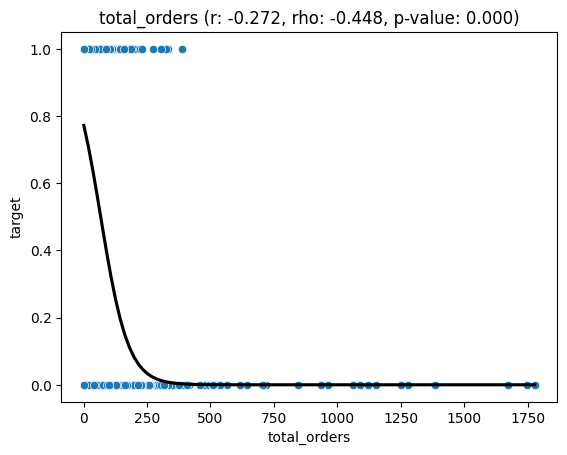

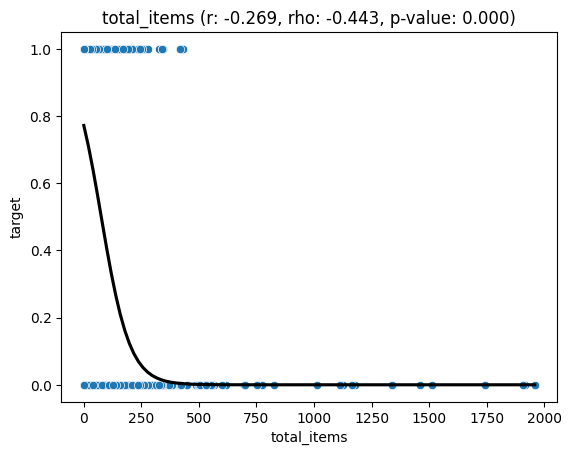

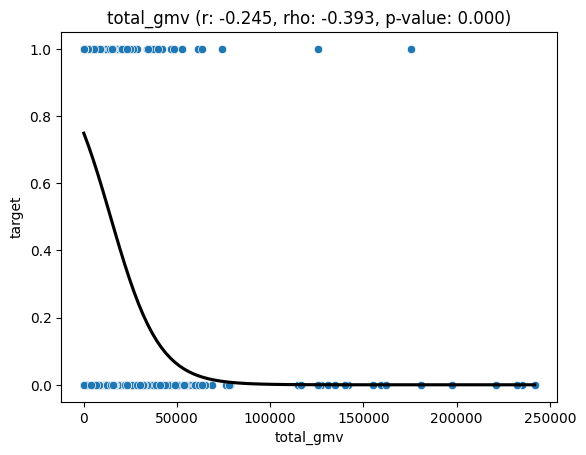

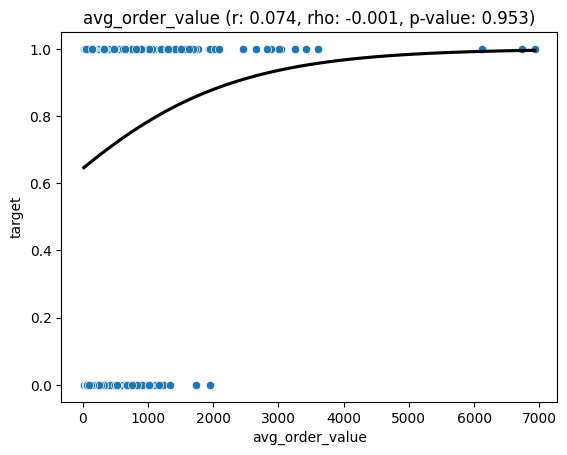

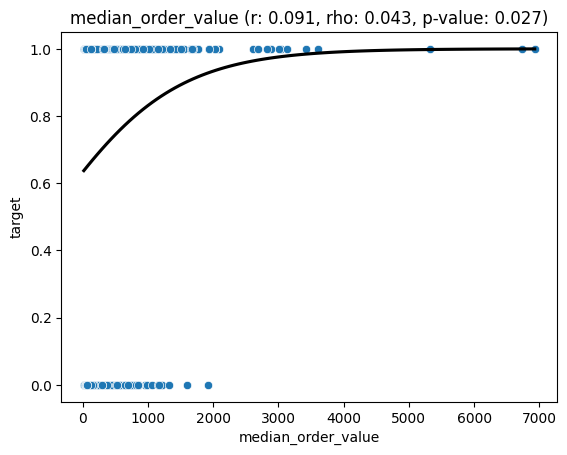

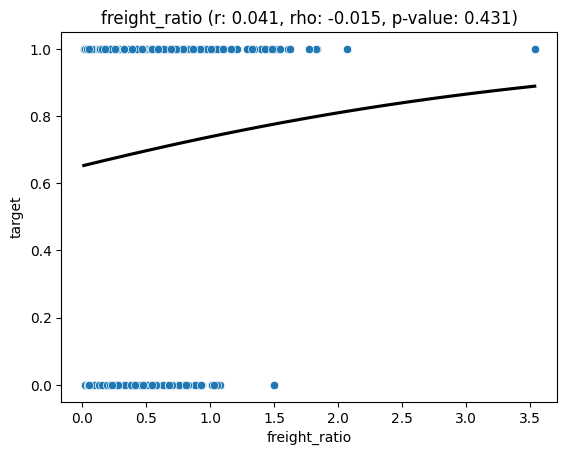

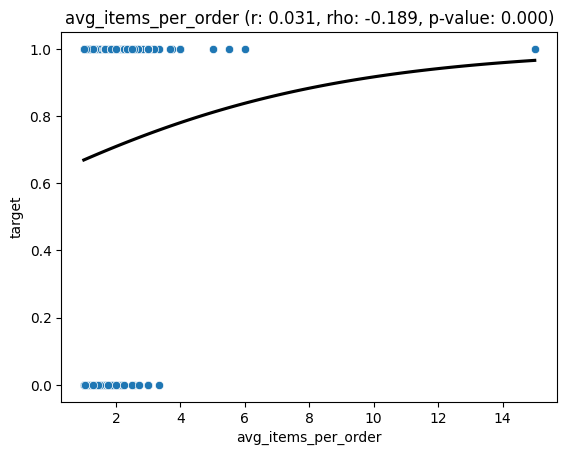

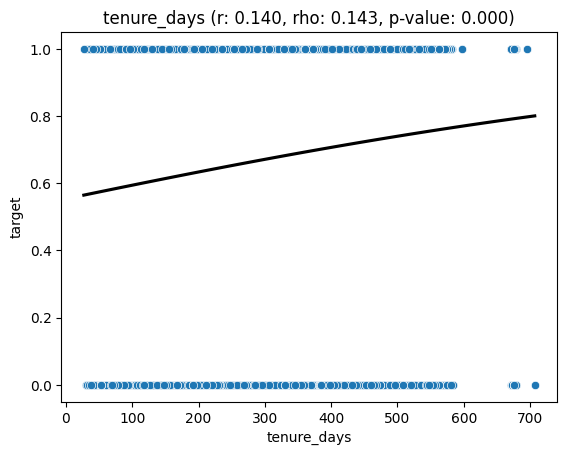

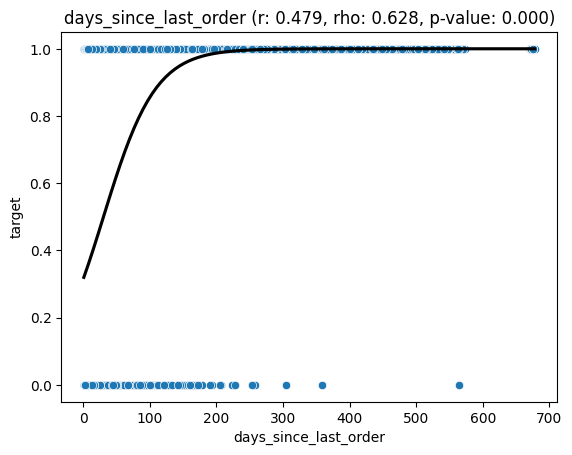

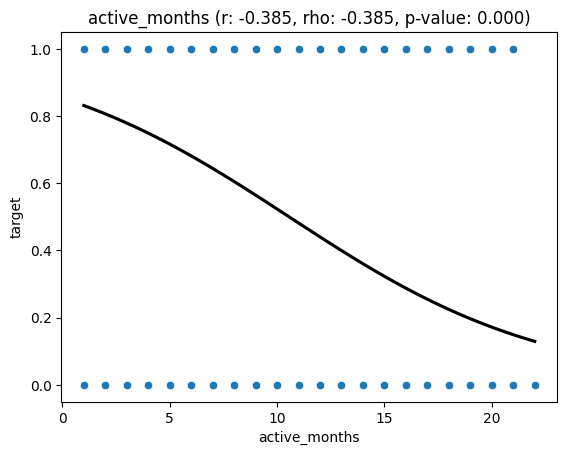

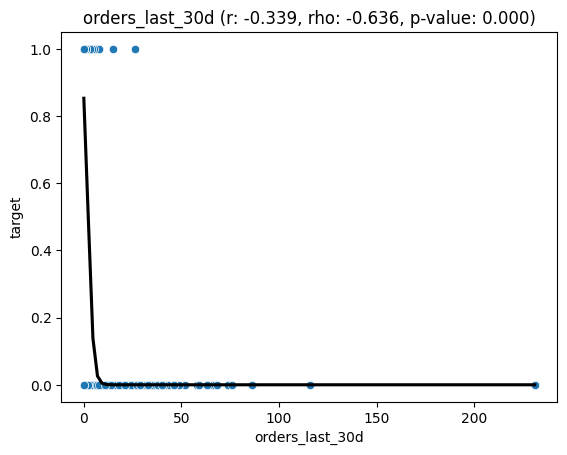

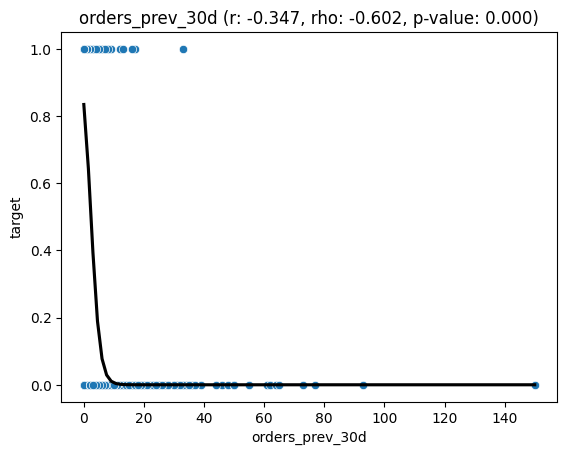

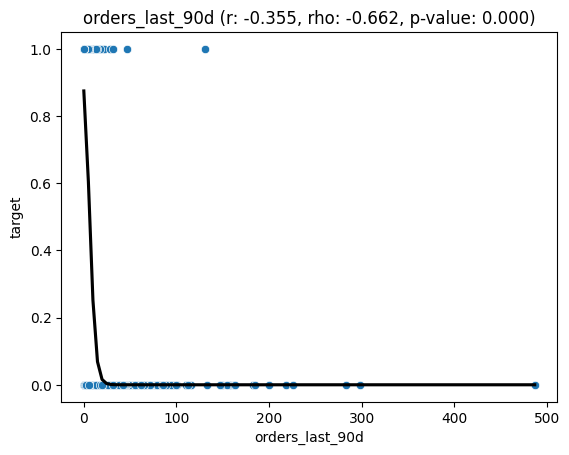

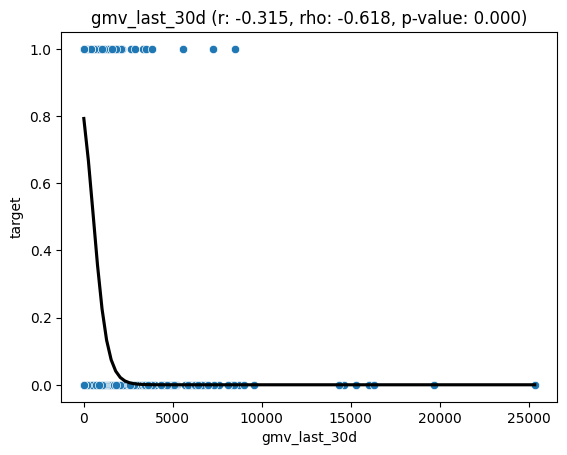

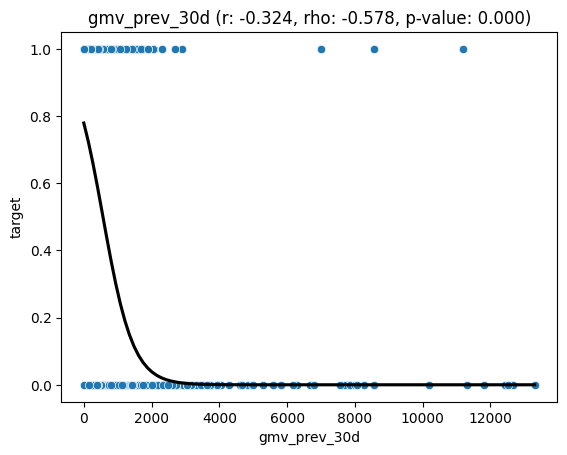

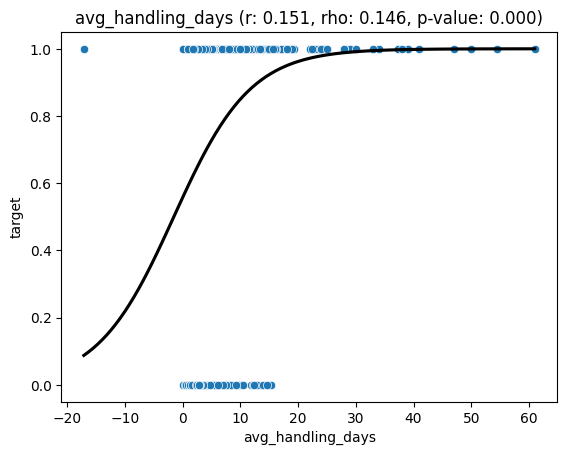

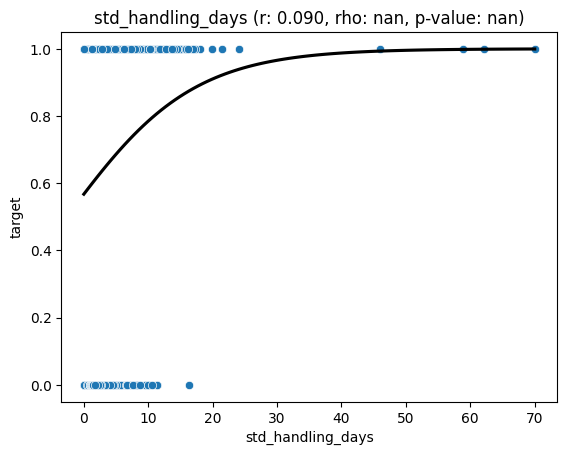

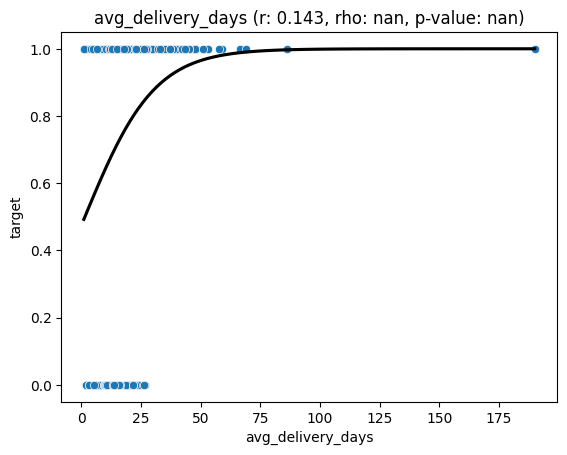

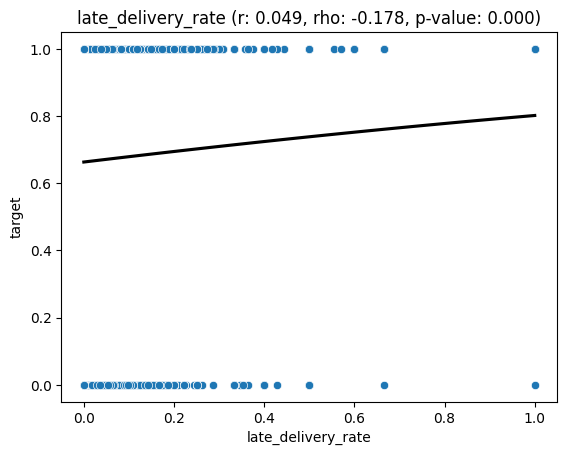

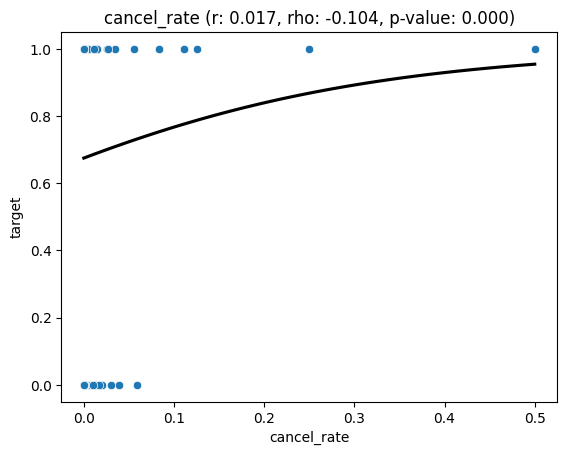

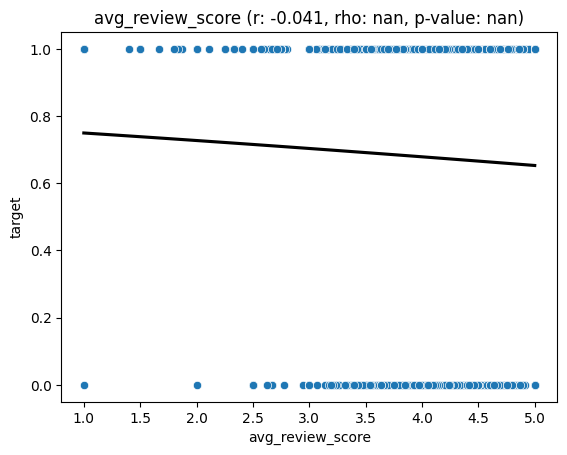

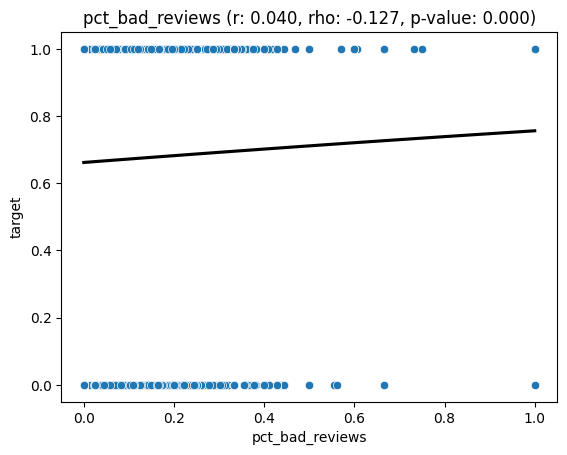

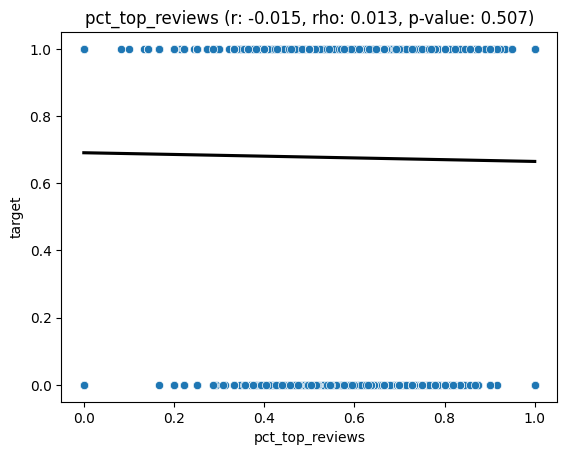

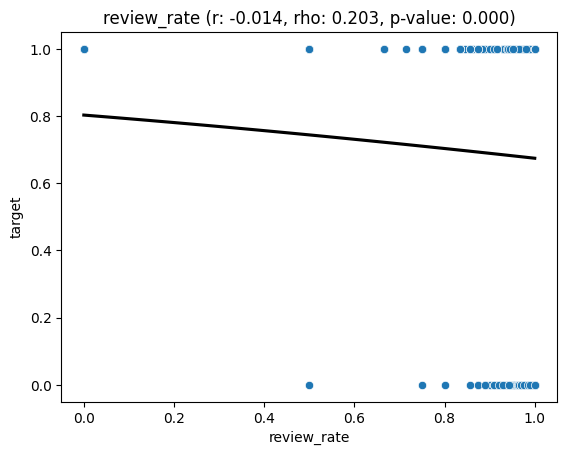

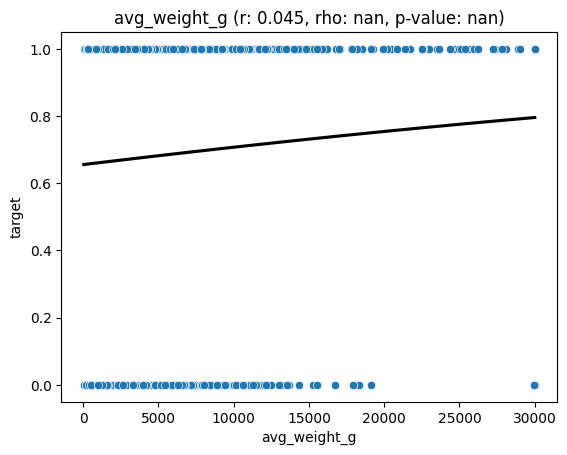

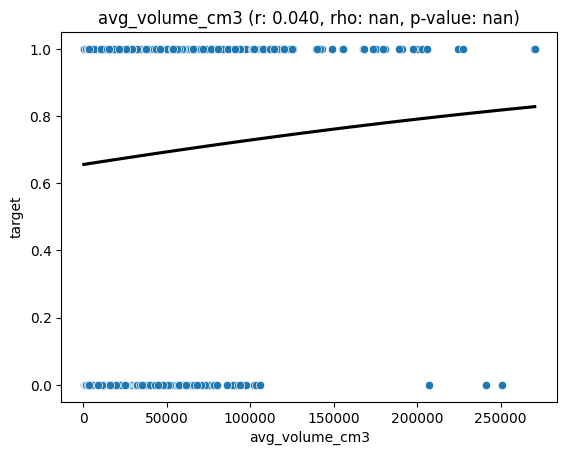

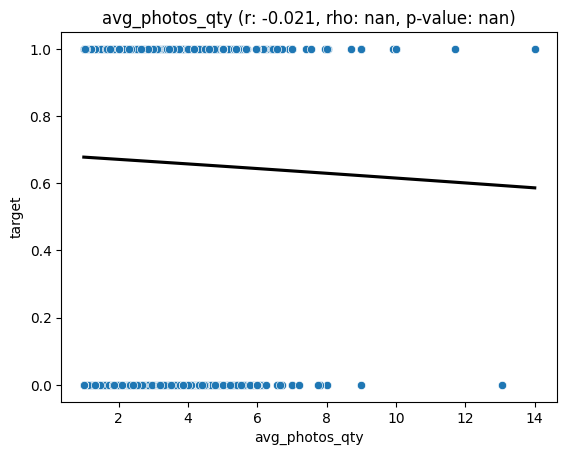

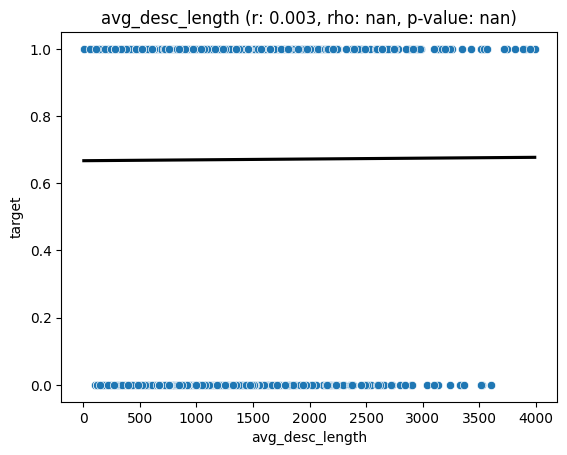

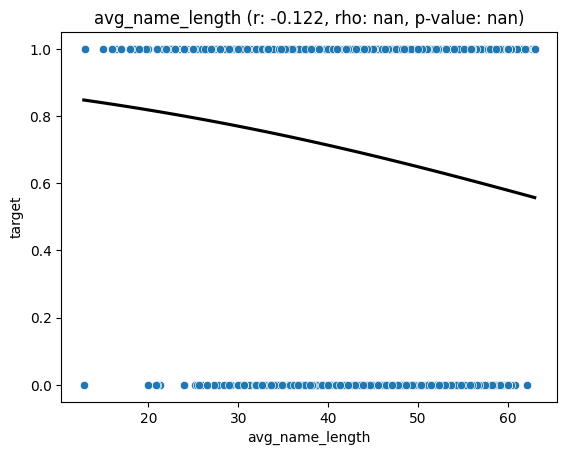

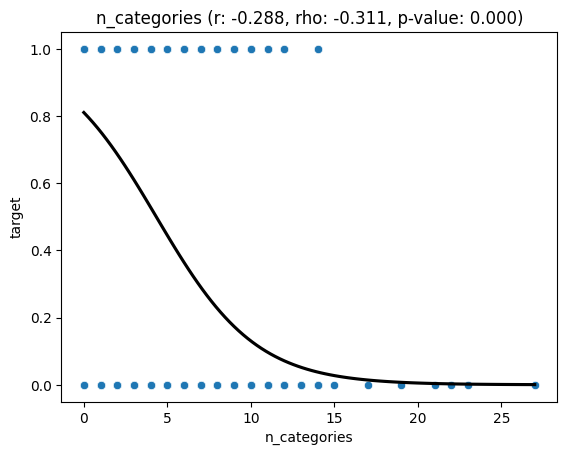

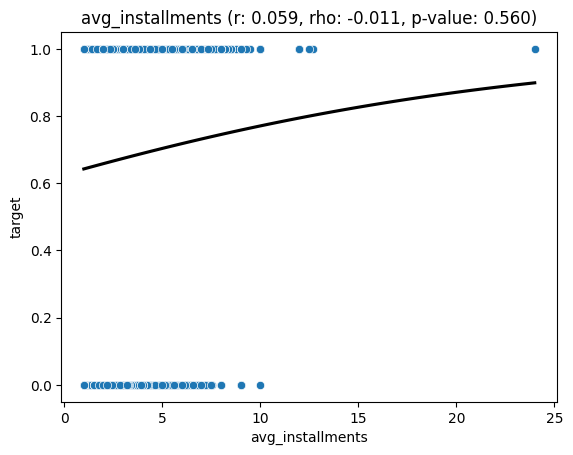

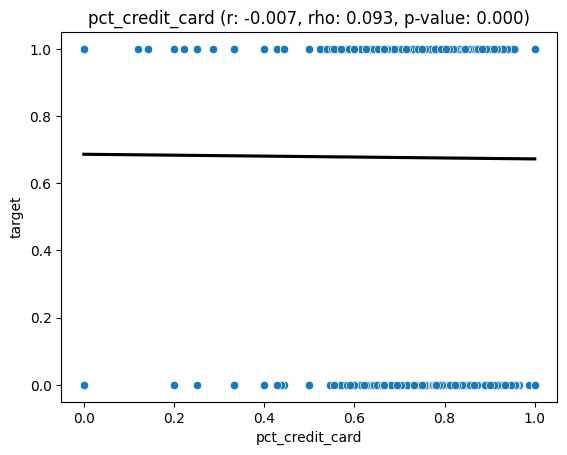

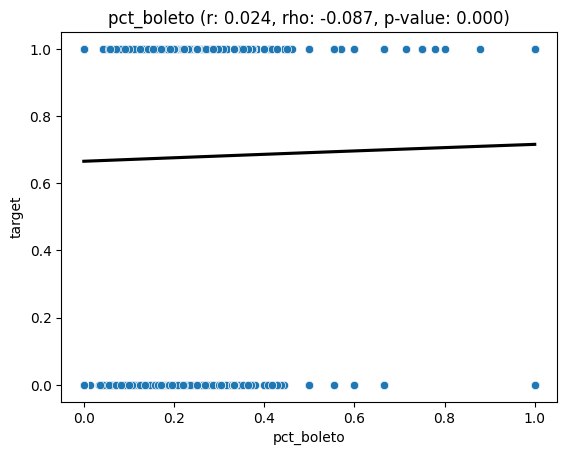

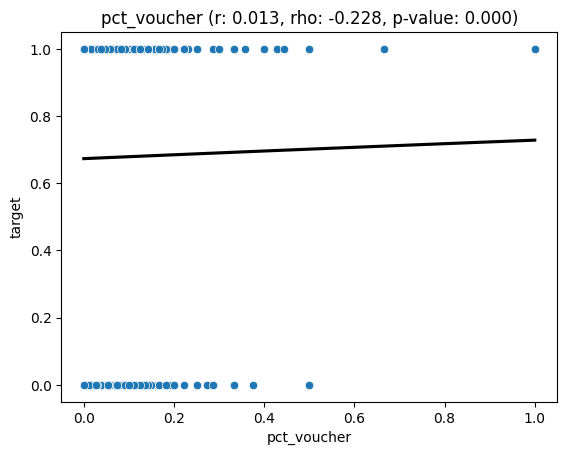

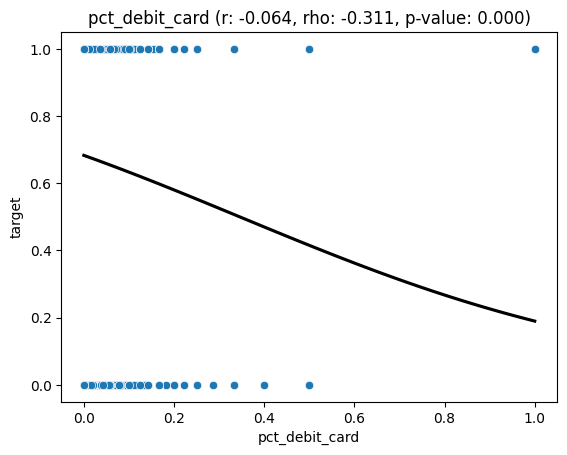

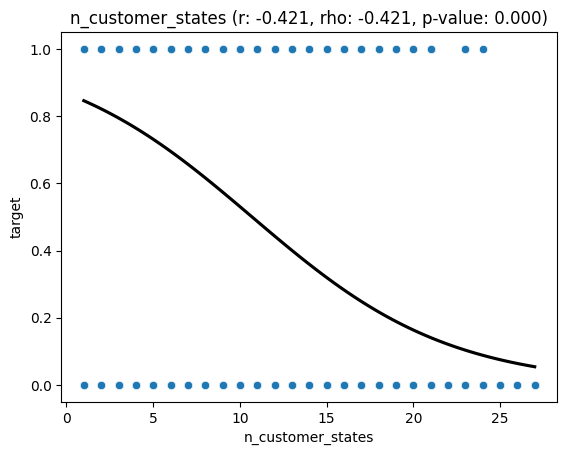

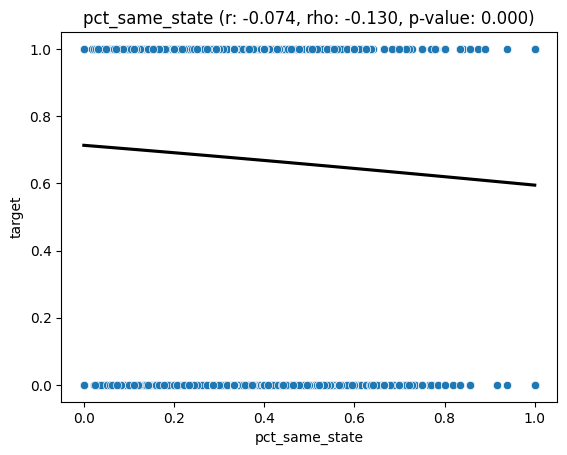

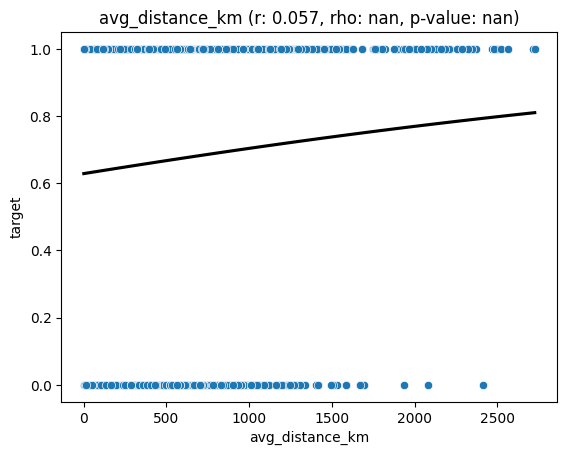

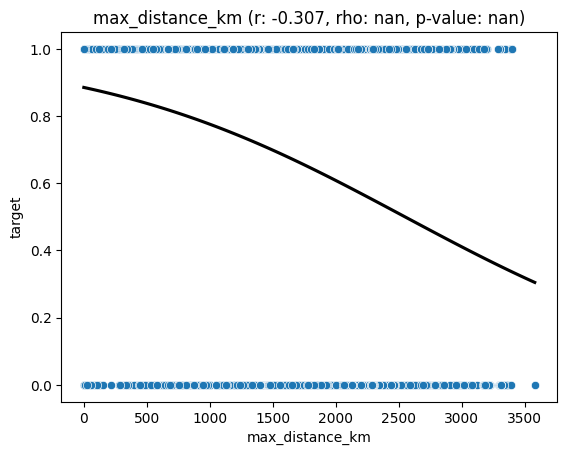

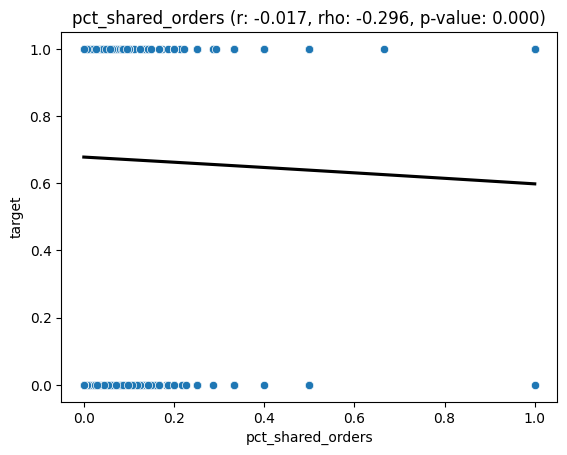

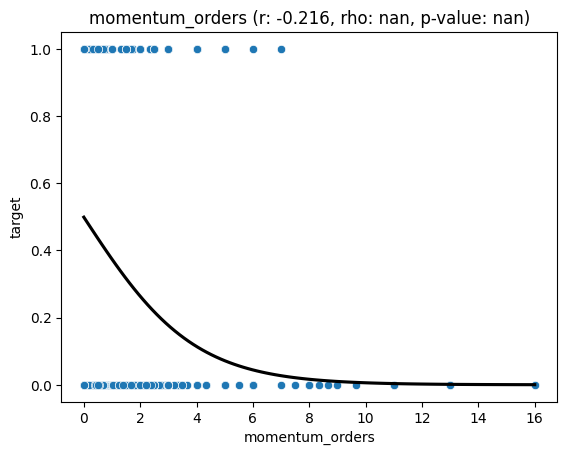

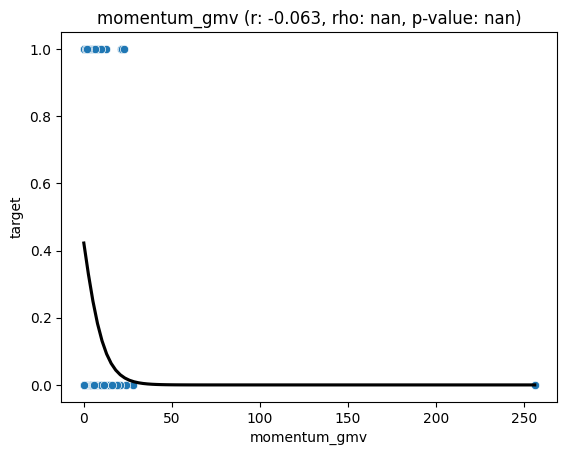

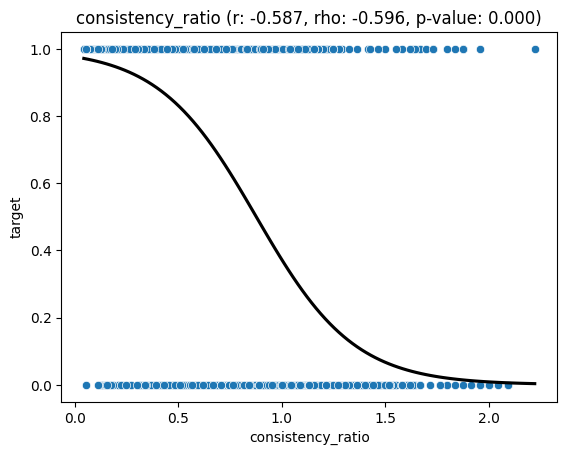

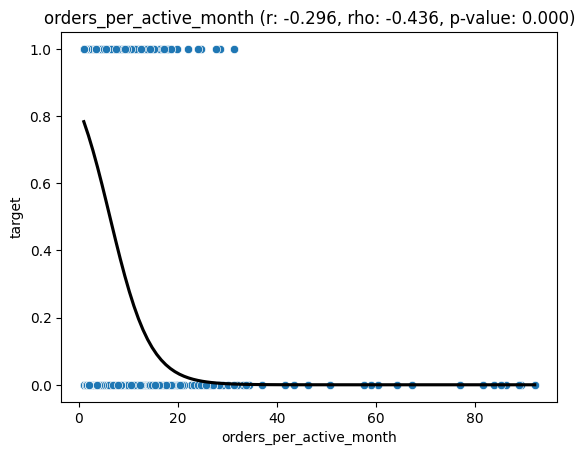

In [41]:
for i in sellers_churn_target_df.select_dtypes('number'):
    if i not in ['target']:
        pearson = sellers_churn_target_df[i].corr(sellers_churn_target_df['target'])
        rho, p_value = stats.spearmanr(sellers_churn_target_df[i], sellers_churn_target_df['target'])
        sns.scatterplot(data=sellers_churn_target_df, x=i, y='target')
        sns.regplot(data=sellers_churn_target_df, x=i, y='target', scatter=False, color='black', ci=None, logistic=True)
        plt.title(f'{i} (r: {pearson:.3f}, rho: {rho:.3f}, p-value: {p_value:.3f})')
        plt.xlabel(i)
        plt.ylabel('target')
        plt.show()
        print("="*90)

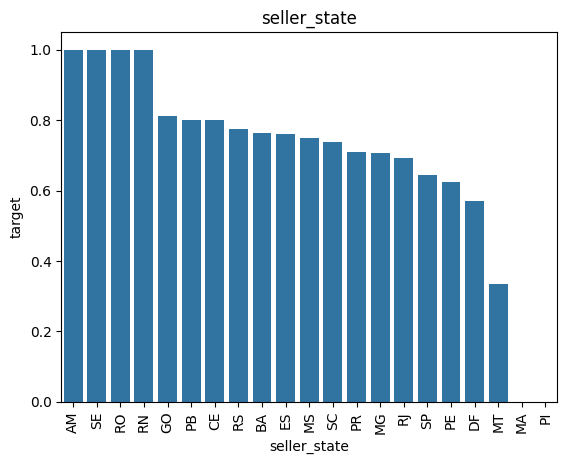

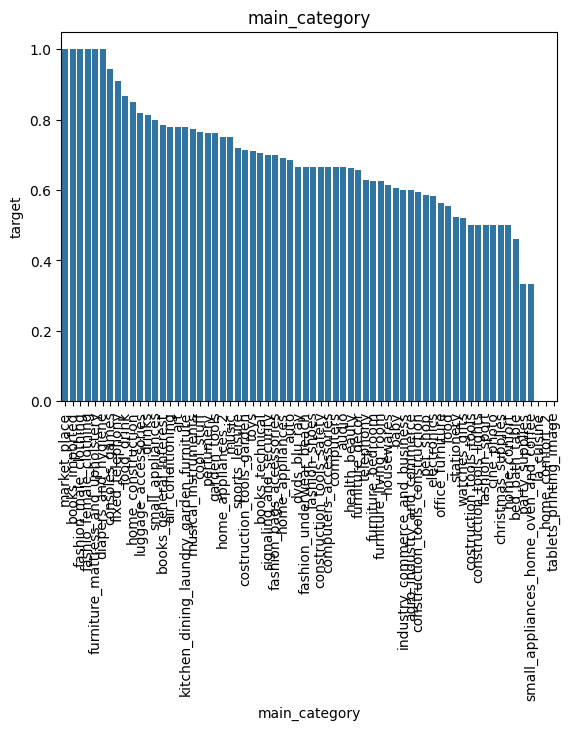

In [42]:
for i in sellers_churn_target_df.select_dtypes('str'):
    if i not in ['seller_id', 'seller_city','churn_status']:
        df_agg=sellers_churn_target_df.groupby(i)['target'].mean().reset_index().sort_values('target',ascending=False)
        sns.barplot(x=i, y='target', data=df_agg)
        plt.title(f'{i}')
        plt.xlabel(i)
        plt.ylabel('target')
        plt.xticks(rotation=90)
        plt.show()
        print("="*90)

## Features Selection

In [43]:
X_raw = sellers_churn_target_df[[
       'total_orders', 'total_items', 'total_gmv',
       'days_since_last_order', 'active_months',
       'orders_last_30d', 'orders_prev_30d', 'orders_last_90d', 'gmv_last_30d',
       'gmv_prev_30d', 
       'n_categories',
       'n_customer_states',
       'max_distance_km', 'momentum_orders',
       'consistency_ratio', 'orders_per_active_month']]
X_raw

,total_orders,total_items,total_gmv,days_since_last_order,active_months,orders_last_30d,orders_prev_30d,orders_last_90d,gmv_last_30d,gmv_prev_30d,n_categories,n_customer_states,max_distance_km,momentum_orders,consistency_ratio,orders_per_active_month
0,4,4.0,174.28,445,3,0,0,0,0.00,0.00,1,4,2467.318628,NaN,0.163934,1.333333
1,24,24.0,1022.36,3,5,5,2,15,378.13,114.17,2,8,1493.660783,2.5,1.415094,4.800000
2,26,36.0,2255.44,318,8,0,0,0,0.00,0.00,4,8,1321.014574,NaN,0.447761,3.250000
3,2,2.0,79.73,252,2,0,0,0,0.00,0.00,1,2,646.678910,NaN,0.223048,1.000000
4,4,4.0,354.61,460,3,0,0,0,0.00,0.00,1,3,2140.156720,NaN,0.179283,1.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090,22,23.0,1954.88,13,6,2,4,6,180.34,327.35,1,8,2126.368082,0.5,0.937500,3.666667
3091,2,2.0,248.61,49,1,0,2,2,0.00,248.61,1,2,2196.818241,0.0,0.566038,2.000000
3092,1,1.0,317.37,563,1,0,0,0,0.00,0.00,1,1,320.814918,NaN,0.053286,1.000000
3093,99,127.0,6718.59,3,8,11,2,20,837.60,141.67,3,14,2290.725901,5.5,1.132075,12.375000


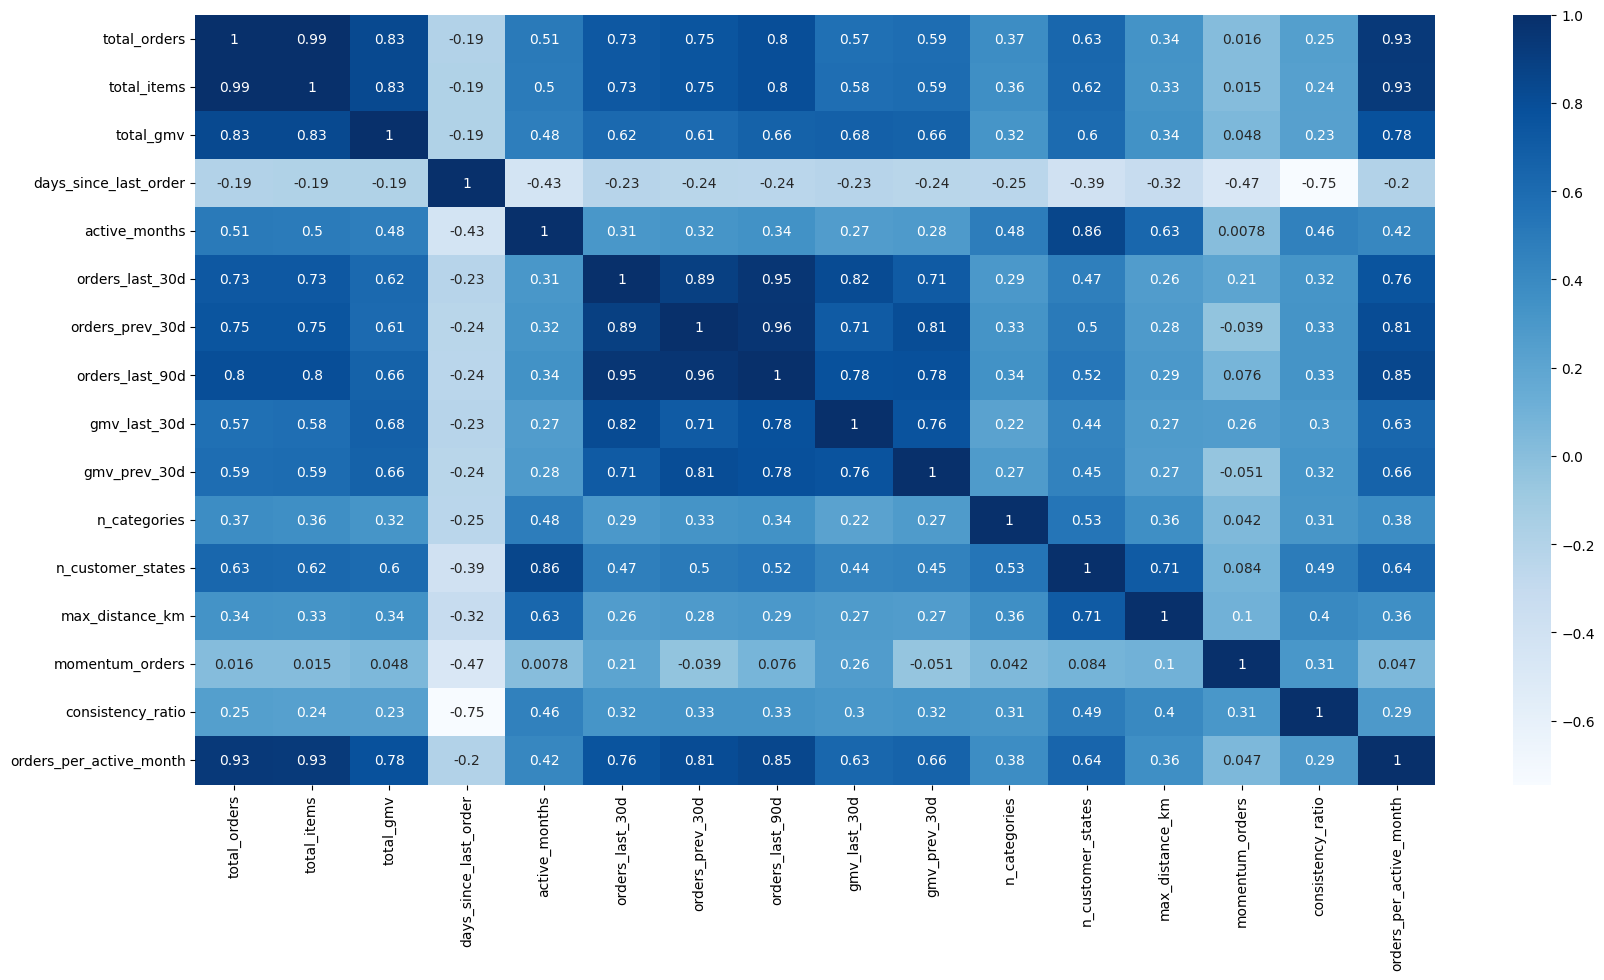

In [44]:
plt.figure(figsize=(20,10))
sns.heatmap(sellers_churn_target_df[X_raw.columns].select_dtypes('number').corr(),annot=True,cmap='Blues')
plt.show()

In [45]:
X = X_raw[[
       'total_orders',
       'days_since_last_order', 'active_months',
       'orders_last_90d',
       'gmv_prev_30d', 
       'n_categories',
       'max_distance_km', 'momentum_orders',
       'consistency_ratio']]
X

,total_orders,days_since_last_order,active_months,orders_last_90d,gmv_prev_30d,n_categories,max_distance_km,momentum_orders,consistency_ratio
0,4,445,3,0,0.00,1,2467.318628,NaN,0.163934
1,24,3,5,15,114.17,2,1493.660783,2.5,1.415094
2,26,318,8,0,0.00,4,1321.014574,NaN,0.447761
3,2,252,2,0,0.00,1,646.678910,NaN,0.223048
4,4,460,3,0,0.00,1,2140.156720,NaN,0.179283
...,...,...,...,...,...,...,...,...,...
3090,22,13,6,6,327.35,1,2126.368082,0.5,0.937500
3091,2,49,1,2,248.61,1,2196.818241,0.0,0.566038
3092,1,563,1,0,0.00,1,320.814918,NaN,0.053286
3093,99,3,8,20,141.67,3,2290.725901,5.5,1.132075


## Split Train and Test

In [47]:
X

,total_orders,days_since_last_order,active_months,orders_last_90d,gmv_prev_30d,n_categories,max_distance_km,momentum_orders,consistency_ratio
0,4,445,3,0,0.00,1,2467.318628,NaN,0.163934
1,24,3,5,15,114.17,2,1493.660783,2.5,1.415094
2,26,318,8,0,0.00,4,1321.014574,NaN,0.447761
3,2,252,2,0,0.00,1,646.678910,NaN,0.223048
4,4,460,3,0,0.00,1,2140.156720,NaN,0.179283
...,...,...,...,...,...,...,...,...,...
3090,22,13,6,6,327.35,1,2126.368082,0.5,0.937500
3091,2,49,1,2,248.61,1,2196.818241,0.0,0.566038
3092,1,563,1,0,0.00,1,320.814918,NaN,0.053286
3093,99,3,8,20,141.67,3,2290.725901,5.5,1.132075


In [48]:
y = sellers_churn_target_df['target']
y

0       1
1       0
2       1
3       1
4       1
       ..
3090    0
3091    0
3092    1
3093    0
3094    0
Name: target, Length: 2692, dtype: Int32

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
for i in [X_train, X_test, y_train, y_test]:
    print(i.shape)

(2153, 9)
(539, 9)
(2153,)
(539,)


## Feature Engineering

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ('Numerical', Pipeline([('scaler', RobustScaler()),
                                ('imputer', SimpleImputer(strategy='median', add_indicator=True))]),
        X_train.select_dtypes(include=['Int64', 'float64']).columns)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output 

In [52]:
X_train_preprocessor = preprocessor.fit_transform(X_train)
X_train_preprocessor = pd.DataFrame(X_train_preprocessor,columns=preprocessor.get_feature_names_out(),index=X_train.index)
X_train_preprocessor

,total_orders,days_since_last_order,active_months,orders_last_90d,gmv_prev_30d,n_categories,max_distance_km,momentum_orders,consistency_ratio,missingindicator_max_distance_km,missingindicator_momentum_orders
1615,0.318182,0.301435,1.000000,-0.2,0.000000,1.0,-0.364872,0.000000,-0.062061,0.0,1.0
2144,0.136364,0.177033,0.166667,-0.2,0.000000,3.0,0.167885,0.000000,-0.141509,0.0,1.0
2192,-0.272727,-0.004785,-0.333333,0.0,0.936842,0.0,-0.928504,-0.759494,0.127289,0.0,0.0
68,-0.272727,0.143541,-0.333333,-0.2,0.000000,0.0,-0.565483,0.000000,-0.501708,0.0,1.0
3029,-0.227273,1.885167,-0.166667,-0.2,0.000000,1.0,-0.237647,0.000000,-0.575885,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1872,-0.318182,2.387560,-0.500000,-0.2,0.000000,0.0,-0.754720,0.000000,-0.759078,0.0,1.0
1244,-0.181818,1.110048,0.000000,-0.2,0.000000,0.0,-0.374343,0.000000,-0.427446,0.0,1.0
1285,-0.090909,-0.272727,-0.166667,0.2,0.000000,1.0,-0.530254,0.000000,0.204407,0.0,1.0
1471,-0.318182,-0.110048,-0.500000,0.0,0.286392,0.0,-0.482517,-0.759494,0.335715,0.0,0.0


## Modeling

In [54]:
# Base Model

logreg = LogisticRegression(random_state=42)
knn    = KNeighborsClassifier()
tree   = DecisionTreeClassifier(random_state=42)
base   = [('logreg', logreg), ('knn', knn), ('tree', tree)]


models = {
    'Logistic Regression': logreg,
    'KNN': knn,
    'Decision Tree': tree,
    'Hard Voting': VotingClassifier(estimators=base, voting='hard'),
    'Soft Voting': VotingClassifier(estimators=base, voting='soft'),
    'Stacking': StackingClassifier(
        estimators=base,
        final_estimator=LogisticRegression(random_state=42),
        cv=5),
    'Bagging': BaggingClassifier(estimator=tree, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=0),
}

scoring = {
    'f2': make_scorer(fbeta_score, beta=2, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1)
}


results = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    for name, model in tqdm(models.items(), total=len(models), desc='Base Model: '):
        pipe = Pipeline([('prep', preprocessor), ('model', model)])
        cv = cross_validate(pipe, X_train_preprocessor, y_train, cv=5, scoring=scoring, return_train_score=True)

        results.append({
            'Model': name,
            'Train F2': cv['train_f2'].round(3),
            'Validation F2': cv['test_f2'].round(3),
            'Mean Train F2': cv['train_f2'].mean().round(3),
            'Mean Validation F2': cv['test_f2'].mean().round(3),
            'Diff Mean F2': (cv['train_f2'].mean()- cv['test_f2'].mean()).round(3),

            'Train Recall': cv['train_recall'].round(3),
            'Validation Recall': cv['test_recall'].round(3),
            'Mean Train Recall': cv['train_recall'].mean().round(3),
            'Mean Validation Recall': cv['test_recall'].mean().round(3),
            'Diff Mean Recall': (cv['train_recall'].mean() - cv['test_recall'].mean()).round(3)
        })

base_model_df = pd.DataFrame(results).sort_values('Mean Validation F2', ascending=False)
base_model_df

Base Model: 100%|██████████| 13/13 [00:11<00:00,  1.10it/s]


,Model,Train F2,Validation F2,Mean Train F2,Mean Validation F2,Diff Mean F2,Train Recall,Validation Recall,Mean Train Recall,Mean Validation Recall,Diff Mean Recall
5,Stacking,"[0.914, 0.893, 0.915, 0.906, 0.911]","[0.887, 0.928, 0.879, 0.891, 0.885]",0.908,0.894,0.014,"[0.926, 0.903, 0.926, 0.917, 0.921]","[0.901, 0.949, 0.887, 0.897, 0.89]",0.919,0.905,0.014
0,Logistic Regression,"[0.896, 0.884, 0.892, 0.895, 0.888]","[0.878, 0.921, 0.87, 0.891, 0.875]",0.891,0.887,0.004,"[0.907, 0.892, 0.902, 0.906, 0.897]","[0.89, 0.938, 0.877, 0.897, 0.877]",0.901,0.896,0.005
3,Hard Voting,"[0.941, 0.941, 0.942, 0.939, 0.929]","[0.87, 0.91, 0.871, 0.869, 0.871]",0.938,0.878,0.060,"[0.948, 0.949, 0.951, 0.946, 0.933]","[0.88, 0.925, 0.88, 0.87, 0.877]",0.945,0.886,0.059
8,Gradient Boosting,"[0.935, 0.935, 0.939, 0.938, 0.929]","[0.874, 0.907, 0.879, 0.866, 0.864]",0.935,0.878,0.057,"[0.946, 0.946, 0.949, 0.946, 0.935]","[0.88, 0.925, 0.887, 0.866, 0.863]",0.945,0.884,0.060
10,CatBoost,"[0.968, 0.967, 0.973, 0.972, 0.971]","[0.869, 0.907, 0.884, 0.865, 0.868]",0.970,0.878,0.092,"[0.976, 0.976, 0.983, 0.979, 0.98]","[0.873, 0.921, 0.89, 0.866, 0.87]",0.979,0.884,0.095
9,AdaBoost,"[0.915, 0.901, 0.888, 0.858, 0.857]","[0.902, 0.919, 0.868, 0.845, 0.833]",0.884,0.873,0.011,"[0.936, 0.916, 0.891, 0.848, 0.848]","[0.921, 0.942, 0.87, 0.836, 0.818]",0.888,0.877,0.010
1,KNN,"[0.915, 0.905, 0.915, 0.913, 0.904]","[0.853, 0.894, 0.86, 0.855, 0.87]",0.910,0.866,0.044,"[0.921, 0.911, 0.924, 0.919, 0.908]","[0.856, 0.904, 0.866, 0.856, 0.877]",0.917,0.872,0.045
4,Soft Voting,"[0.982, 0.983, 0.982, 0.984, 0.983]","[0.867, 0.885, 0.859, 0.856, 0.865]",0.983,0.866,0.117,"[0.986, 0.987, 0.985, 0.988, 0.987]","[0.873, 0.897, 0.863, 0.856, 0.87]",0.987,0.872,0.115
12,LightGBM,"[0.998, 0.997, 0.998, 0.996, 0.997]","[0.862, 0.886, 0.87, 0.841, 0.871]",0.997,0.866,0.132,"[1.0, 1.0, 1.0, 0.997, 0.998]","[0.866, 0.897, 0.877, 0.839, 0.873]",0.999,0.871,0.129
7,Random Forest,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.863, 0.892, 0.858, 0.853, 0.85]",1.000,0.863,0.137,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.866, 0.897, 0.86, 0.853, 0.846]",1.000,0.864,0.136


Logistic Regression was chosen not only because the evaluation score is high, but also this model will not lead to either underfiting or overfiting

## Hyperparameter Tuning

In [56]:
# Hyperparameter Tuning - Logistic Regression
gscv_logreg=GridSearchCV(
    estimator=Pipeline([('prep', preprocessor), ('model', logreg)]),
    param_grid={
        'model__C':[0.001,0.1,1,10,100,1000]
    },
    scoring=make_scorer(fbeta_score, beta=2, pos_label=1),
    cv=5,
    n_jobs=-1,
    return_train_score=True
)
gscv_logreg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","make_scorer(f..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.

In [57]:
tuned_model_df = pd.DataFrame(gscv_logreg.cv_results_).sort_values(by=['mean_test_score'], ascending=False).reset_index(drop=True)
tuned_model_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.081172,0.056591,0.010686,0.002388,0.001,{'model__C': 0.001},0.922775,0.928571,0.913838,0.914714,...,0.921358,0.006089,1,0.920280,0.920046,0.922275,0.923240,0.919681,0.921104,0.001397
1,0.090452,0.055538,0.026787,0.029877,0.100,{'model__C': 0.1},0.879973,0.920965,0.866168,0.899865,...,0.890704,0.018623,2,0.898107,0.886333,0.897263,0.891499,0.889415,0.892523,0.004532
2,0.031828,0.013910,0.004863,0.001173,1.000,{'model__C': 1},0.876184,0.918573,0.869121,0.889946,...,0.888239,0.016939,3,0.894612,0.880204,0.890492,0.885603,0.887644,0.887711,0.004820
3,0.022291,0.008365,0.007482,0.002429,10.000,{'model__C': 10},0.874576,0.915825,0.871935,0.886549,...,0.886810,0.015592,4,0.894068,0.879803,0.888700,0.882703,0.886001,0.886255,0.004926
4,0.018179,0.003963,0.004139,0.001122,100.000,{'model__C': 100},0.874576,0.915825,0.871935,0.886549,...,0.886810,0.015592,4,0.894068,0.880102,0.888700,0.882703,0.885302,0.886175,0.004866
5,0.014848,0.002844,0.003493,0.000253,1000.000,{'model__C': 1000},0.874576,0.915825,0.871935,0.886549,...,0.886810,0.015592,4,0.893916,0.880102,0.888700,0.882703,0.884602,0.886005,0.004849


In [58]:
gscv_logreg.best_params_

{'model__C': 0.001}

In [59]:
gscv_logreg.best_score_

np.float64(0.9213581819688252)

## Predict with Best Model

In [60]:
best_model = gscv_logreg.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['total_orders','days_since_last_order','active_months',..., 'max_distance_km','momentum_orders','consistency_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature

In [61]:
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['total_orders','days_since_last_order','active_months',..., 'max_distance_km','momentum_orders','consistency_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature

In [62]:
y_pred = best_model.predict(X_test)

## Model Evaluation

In [63]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 86,  95],
       [ 17, 341]])

<Axes: >

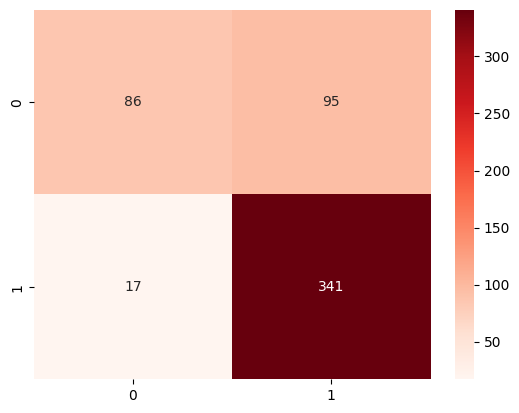

In [64]:
sns.heatmap(cm, annot=True, cmap='Reds',fmt='d')

In [65]:
recall = recall_score(y_test, y_pred, pos_label=1)
recall

0.952513966480447

In [66]:
f2 = fbeta_score(y_test, y_pred, beta=2, pos_label=1)
f2

0.9127408993576017

In [67]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

         0.0      0.835     0.475     0.606       181
         1.0      0.782     0.953     0.859       358

    accuracy                          0.792       539
   macro avg      0.809     0.714     0.732       539
weighted avg      0.800     0.792     0.774       539



## Features Importance

In [68]:
clf = best_model[-1]
feature_names = best_model[:-1].get_feature_names_out()

coef_df = (pd.DataFrame({
              'feature'         : feature_names,
              'coeff'           : clf.coef_[0],
              'odds_ratio'      : np.exp(clf.coef_[0]),
           })
           .assign(abs_coef=lambda d: d['coeff'].abs())
           .sort_values('abs_coef', ascending=False)
           .drop(columns='abs_coef')
           .reset_index(drop=True))
coef_df

,feature,coeff,odds_ratio
0,orders_last_90d,-0.234918,0.790636
1,days_since_last_order,0.178565,1.195500
2,consistency_ratio,-0.158697,0.853254
3,missingindicator_momentum_orders,0.118884,1.126239
4,gmv_prev_30d,-0.108716,0.896986
5,active_months,-0.079794,0.923306
6,momentum_orders,-0.077500,0.925427
7,total_orders,-0.070998,0.931464
8,n_categories,-0.067259,0.934953
9,max_distance_km,-0.038520,0.962213


<Axes: xlabel='coeff', ylabel='feature'>

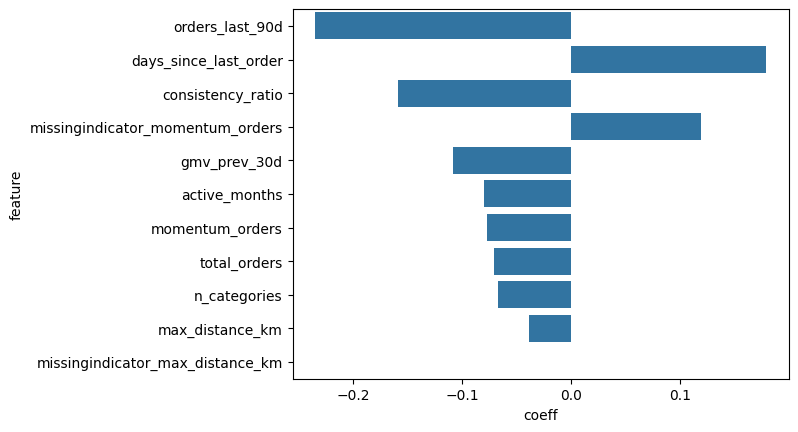

In [69]:
sns.barplot(data=coef_df, x='coeff', y='feature')

<Axes: xlabel='odds_ratio', ylabel='feature'>

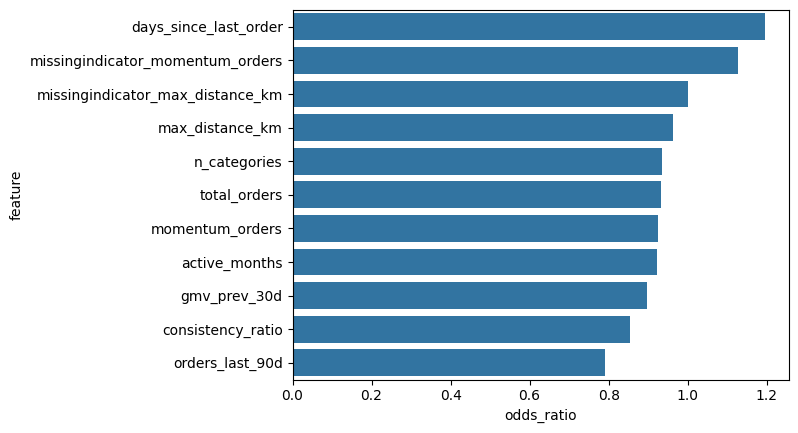

In [70]:
sns.barplot(data=coef_df.sort_values('odds_ratio', ascending=False), x='odds_ratio', y='feature')

## Save Model

In [71]:
pickle.dump(best_model, open('model_seller_churn.sav', 'wb'))